### Objectives

**Task 1: Data Cleaning and Preprocessing**
- Clean dataset
- Make data consistent and ready for analysis.

**Task 2: Exploratory Data Analysis (EDA)**
- The aim here is to explore the cleaned dataset to uncover patterns, identify trends, and formulate initial hypotheses.

**Task 3: Basic Data Visualization**
- This task focuses specifically on the ability to create clear and informative plots to communicate findings effectively.

In [118]:
# loading dataset 
import pandas as pd

df = pd.read_csv('datasets/StockPrices.csv')
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [120]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [121]:
# checking for missing values
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [122]:
# filling in missing values with mean of the open column
df['open'] = df['open'].fillna(df['open'].mean())

# Also handle missing values in high and low columns
df['high'] = df['high'].fillna(df['high'].mean())
df['low'] = df['low'].fillna(df['low'].mean())

# Verify all missing values are handled
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [123]:
# Data validation checks

# Checking if high is greater or equal to low for all records
invalid_high_low = df[df['high'] < df['low']]
print(f"Records where high < low: {len(invalid_high_low)}")

# Checking for negative prices on all price columns
negative_prices = df[(df['open'] < 0) | (df['high'] < 0) | (df['low'] < 0) | (df['close'] < 0)]
print(f"Records with negative prices: {len(negative_prices)}")

# Checking for zero volumes
zero_volume = df[df['volume'] == 0]
print(f"Records with zero volume: {len(zero_volume)}")

Records where high < low: 1
Records with negative prices: 0
Records with zero volume: 4


In [124]:

# Displaying rows with problems for inspection
if len(invalid_high_low) > 0:
    print("Invalid high < low column\n")
    print(invalid_high_low[['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']])

if len(zero_volume) > 0:
    print("Zero volume records\n")
    print(zero_volume[['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']].head(10))


Invalid high < low column

      symbol        date   open    high    low   close   volume
45501    AOS  2014-05-19  23.89  23.595  23.85  24.445  1944854
Zero volume records

       symbol        date       open       high        low  close  volume
249223    DHR  2016-01-12  86.352275  87.132562  85.552467  88.55       0
249438      O  2016-01-12  86.352275  87.132562  85.552467  52.43       0
278801     UA  2016-04-07  86.352275  87.132562  85.552467  41.56       0
308365    FTV  2016-07-01  86.352275  87.132562  85.552467  49.54       0


In [125]:
# Data  row Corrections

#Fixing invalid high < low records
invalid_high_low = df[df['high'] < df['low']]
#Swapping high and low values
for value in invalid_high_low.index:
    if df.loc[value, 'low'] > df.loc[value, 'high']:
        df.loc[value, 'high'], df.loc[idx, 'low'] = df.loc[value, 'low'], df.loc[value, 'high']
        print(f"Swapped high/low values for {df.loc[idx, 'symbol']} on {df.loc[idx, 'date']}")
    
# Verifying fix
remaining_invalid = df[df['high'] < df['low']]
print(f"Remaining invalid records after fix: {len(remaining_invalid)}\n")

# Handling zero volume records
zero_volume = df[df['volume'] == 0]

# Replacing zero volumes with median volume for that stock symbol
for value in zero_volume.index:
    symbol = df.loc[value, 'symbol']
    # Calculate median volume for the specific stock
    median_volume = df[df['symbol'] == symbol]['volume'].median()
    # If median is still 0, use overall median volume
    if median_volume == 0:
        median_volume = df['volume'].median()
        
    df.loc[value, 'volume'] = median_volume
    print(f"Updated volume for {symbol} on {df.loc[value, 'date']} to {median_volume:,.0f}")
    
# Verifying fix
remaining_zero_volume = df[df['volume'] == 0]
print(f"Remaining zero volume records after fix: {len(remaining_zero_volume)}")


Swapped high/low values for FTV on 2016-07-01
Remaining invalid records after fix: 0

Updated volume for DHR on 2016-01-12 to 2,628,478
Updated volume for O on 2016-01-12 to 1,681,746
Updated volume for UA on 2016-04-07 to 2,568,946
Updated volume for FTV on 2016-07-01 to 1,266,257
Remaining zero volume records after fix: 0


In [126]:
# Final Data Validation checks

# Re-running all validation checks
invalid_high_low = df[df['high'] < df['low']]
negative_prices = df[(df['open'] < 0) | (df['high'] < 0) | (df['low'] < 0) | (df['close'] < 0)]
zero_volume = df[df['volume'] == 0]

print(f"Records where high < low: {len(invalid_high_low)}")
print(f"Records with negative prices: {len(negative_prices)}")
print(f"Records with zero volume: {len(zero_volume)}")


Records where high < low: 0
Records with negative prices: 0
Records with zero volume: 0


In [127]:
# Check for extremely high prices (potential outliers)
price_columns = ['open', 'high', 'low', 'close']
for col in price_columns:
    q99 = df[col].quantile(0.99)
    outliers = df[df[col] > q99 * 10]  # Prices 10x above 99th percentile
    print(f"Potential outliers in {col}: {len(outliers)} records")


Potential outliers in open: 0 records
Potential outliers in high: 0 records
Potential outliers in low: 0 records
Potential outliers in close: 0 records


In [128]:
# checking for duplicate rows
df.duplicated().sum()
print("No duplicate rows found" if df.duplicated().sum() == 0 else "Duplicate rows found")

No duplicate rows found


In [129]:
# check if all dates have correct format 
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print("All dates are in correct format" if df['date'].notnull().all() else "There are invalid dates")


All dates are in correct format


In [130]:
# Saving the cleaned dataset
df.to_csv('../Prepared_Datasets/Cleaned_StockPrices.csv', index=False)

In [131]:
df = pd.read_csv('../Prepared_Datasets/Cleaned_StockPrices.csv')
df.describe()

,open,high,low,close,volume
count,497472.000000,497472.000000,497472.000000,497472.000000,4.974720e+05
mean,86.352275,87.132563,85.552343,86.369082,4.253627e+06
std,101.470106,102.311239,100.570187,101.472407,8.232133e+06
min,1.620000,1.690000,1.500000,1.590000,3.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080179e+06
50%,64.970000,65.560000,64.360000,64.980000,2.084948e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [132]:
# checking which stock is there and print it in a list
stock_list = df['symbol'].unique().tolist()
print(stock_list)

['AAL', 'AAPL', 'AAP', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADS', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALLE', 'ALL', 'ALXN', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMG', 'AMP', 'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APC', 'APD', 'APH', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AYI', 'AZO', 'A', 'BAC', 'BAX', 'BA', 'BBT', 'BBY', 'BDX', 'BEN', 'BF.B', 'BIIB', 'BK', 'BLK', 'BLL', 'BMY', 'BRK.B', 'BSX', 'BWA', 'BXP', 'CAG', 'CAH', 'CAT', 'CA', 'CBG', 'CBOE', 'CBS', 'CB', 'CCI', 'CCL', 'CDNS', 'CELG', 'CERN', 'CF', 'CHD', 'CHK', 'CHRW', 'CHTR', 'CINF', 'CI', 'CLX', 'CL', 'CMA', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL', 'COO', 'COP', 'COST', 'COTY', 'CPB', 'CRM', 'CSCO', 'CSX', 'CTAS', 'CTL', 'CTSH', 'CTXS', 'CVS', 'CVX', 'CXO', 'C', 'DAL', 'DE', 'DFS', 'DGX', 'DG', 'DHI', 'DHR', 'DISCA', 'DISCK', 'DISH', 'DIS', 'DLR', 'DLTR', 'DOV', 'DPS

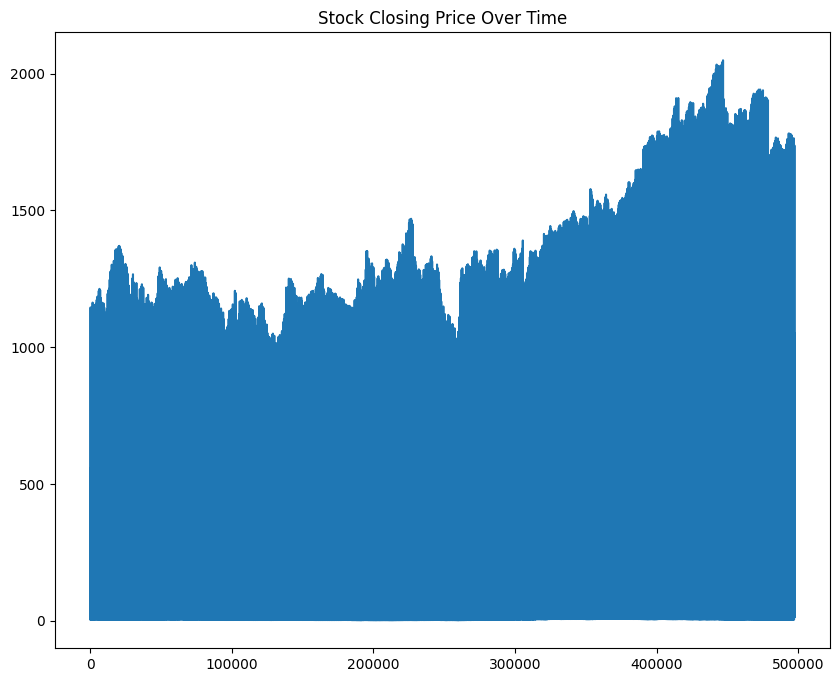

In [133]:
# plotting closing price over time
import matplotlib.pyplot as plt

plt.figure(figsize=[10,8])
plt.title('Stock Closing Price Over Time')
plt.plot(df['close'])
plt.show()


In [134]:
# Complete list of all letters in your dataset
all_letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 
               'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

# Count stocks per letter
letter_counts = {}
for letter in all_letters:
    count = len(df[df['symbol'].str.startswith(letter)]['symbol'].unique())
    letter_counts[letter] = count

print("Stocks per letter:")
for letter, count in sorted(letter_counts.items()):
    print(f"{letter}: {count} stocks")

Stocks per letter:
A: 59 stocks
B: 19 stocks
C: 51 stocks
D: 24 stocks
E: 25 stocks
F: 21 stocks
G: 16 stocks
H: 25 stocks
I: 18 stocks
J: 7 stocks
K: 13 stocks
L: 16 stocks
M: 34 stocks
N: 22 stocks
O: 6 stocks
P: 32 stocks
Q: 2 stocks
R: 16 stocks
S: 28 stocks
T: 19 stocks
U: 13 stocks
V: 12 stocks
W: 15 stocks
X: 8 stocks
Y: 1 stocks
Z: 3 stocks


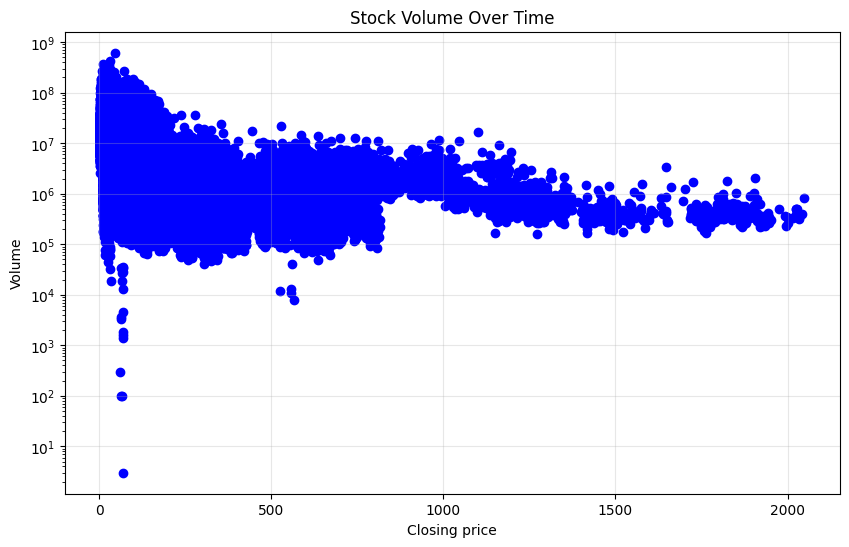

In [135]:
# Show volume distribution as a scatter plot

plt.figure(figsize=(10, 6))
plt.scatter(df['close'], df['volume'], color='blue')
plt.title('Stock Volume Over Time')
plt.xlabel('Closing price')
plt.ylabel('Volume')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

## Stock Prices Dataset Analysis Summary

- **Dataset Size**: 497 turned to 472 observations across multiple stocks
- **Missing Values**: 11 missing values in 'open' column, 8 in 'high' and 'low' columns
- **Data Types**: 4 numerical price features (float64), 1 volume feature (int64), 2 categorical features (object)
- **Duplicate Records**: No duplicate rows found
- **Date Format**: All dates successfully converted to datetime format

#### Cleaning Actions Taken
1. Filled missing values in 'open' column with mean value
2. Verified date format conversion
3. Confirmed no duplicate entries
4. Saved cleaned dataset to `Prepared_Datasets/Cleaned_StockPrices.csv`

#### Stock Distribution by Letter 
Checked for each stock amount by identifying stock by their first letter
- Highest stock: Letter 'A' (59 stocks), 'C' (51 stocks)
- Moderate Distribution: Letters 'M' (34), 'P' (32), 'S' (28), 'N' (22), 'D' (24), 'E' (25), 'F' (21), 'H' (25)
- Lower Distribution: Letters 'Y' (1 stock), 'Q' (2 stocks), 'Z' (3 stocks)
- Total Coverage: All 26 letters represented in dataset

#### Key Visual Findings:
- Price-Volume Relationship: Scatter plot revealed correlation between stock prices and trading volumes
- Stock Distribution: Bar chart analysis showed concentration of stocks in certain letter groups
- Temporal Patterns: Line charts demonstrated price movements over time
